# Descriptive Analytics

## Project: Retail Sales Data Analytics

This notebook focuses on descriptive analytics to answer the big question:

**"What happened?"**

The analysis summarizes historical sales performance using key performance indicators (KPIs), summary statistics, and visualizations. The goal is to provide decision makers with a clear understanding of sales, profitability, customer segments, product categories, and regional performance.

The insights generated in this notebook will also serve as the foundation for the Power BI dashboard developed later in the project.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/processed/feature_engineered_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Profit Margin,Customer Segment Type
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,0.1600,High
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,0.3000,High
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,0.4700,Low
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-0.4000,High
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,0.1125,Low


## Executive KPI Summary

This section will provide a high level overview of the business by calculating key performance indicators (KPIs).

These metrics will help decision makers to quickly understand the overall performance of the business before exploring more detailed analyses.

In [5]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
total_quantity = df['Quantity'].sum()
average_profit_margin = df['Profit Margin'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity Sold:", total_quantity)
print("Average Profit Margin:", average_profit_margin)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009
Total Customers: 793
Total Quantity Sold: 37873
Average Profit Margin: 0.12031392972104521


## KPI Interpretation

The business generated **$2,297,200.86** in total sales across **5,009 customer orders**, serving **793 unique customers**.

These sales resulted in a total profit of **$286,397.02**, indicating that the business is profitable overall.

A total of **37,873 products** were sold during the period covered by the dataset.

The average profit margin was approximately **12.03%**, meaning that, on average, the business earned about 12 cents in profit for every dollar of sales.

These KPIs provide a high-level overview of business performance and establish a baseline for more detailed analyses by product category, region, customer segment, and time.

## Sales and Profit by Product Category

This analysis compares product categories to determine which categories generate the highest sales and profit.

Understanding category performance helps decision-makers identify the strongest-performing product lines and areas that may require improvement.

In [6]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum()

category_summary

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


## Category Performance Insights

Technology generated the highest sales and profit among all product categories, making it the strongest-performing category overall.

Office Supplies generated slightly lower sales than Furniture but significantly higher profit, indicating stronger profitability.

Furniture generated substantial sales revenue but produced relatively low profit compared to the other categories. This suggests that Furniture products may have lower margins, higher discounts, or higher associated costs.

Further investigation is required to understand the factors contributing to the low profitability of the Furniture category.

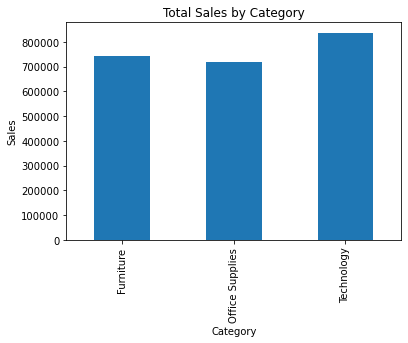

In [7]:
category_summary['Sales'].plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

## Profit by Product Category

While sales measure revenue generated, profit measures how much money the business retains after costs.

Comparing profit across product categories helps identify which product lines contribute most to the company's profitability.

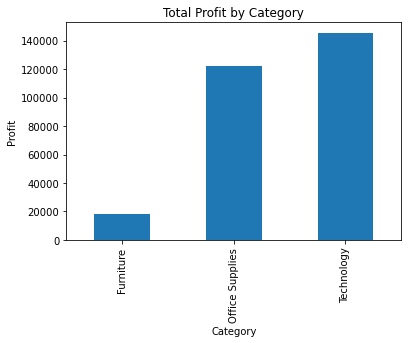

In [8]:
category_summary['Profit'].plot(kind='bar')

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

## Profit by Category Insights

Technology generated the highest total profit, making it the most profitable product category during the period analysed.

Office Supplies generated the second-highest profit despite having the lowest total sales. This suggests that the category operates with relatively strong profitability.

Furniture generated the lowest total profit, even though it achieved higher sales than Office Supplies. This indicates that high sales do not necessarily translate into high profitability.

This finding suggests that the Furniture category should be investigated further to determine whether factors such as discounts, pricing strategies, or product costs are reducing profitability.

## Sales by Region

This analysis compares total sales across the four business regions.

Understanding regional sales performance helps decision-makers identify high-performing markets and regions that may require additional marketing, operational support, or strategic investment.

In [9]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum()

region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


## Sales by Region

This analysis compares total sales across the four business regions.

Understanding regional sales performance helps identify the strongest-performing markets and regions that may require additional attention or strategic investment.

In [10]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum()

region_summary

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


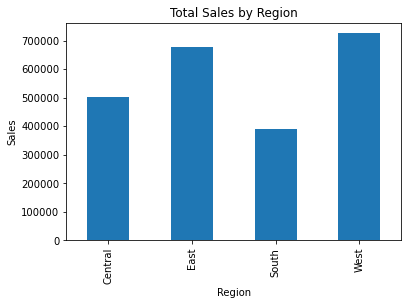

In [11]:
region_summary['Sales'].plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

## Sales by Region Insights

The West region generated the highest total sales, making it the strongest-performing region during the period analysed.

The South region generated the lowest total sales, with the West outperforming it by approximately **$333,736**.

The difference in regional sales performance suggests that customer demand, product mix, or regional business strategies may vary across locations.

Further analysis is required to understand the factors contributing to the stronger performance of the West region and the comparatively lower sales in the South region.

## Profit by Region

This analysis compares total profit across the four business regions.

While sales indicate revenue generation, profit measures how much value each region contributes to the business after costs. Comparing regional profitability helps identify the strongest and weakest performing markets.

In [12]:
region_summary['Profit']

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

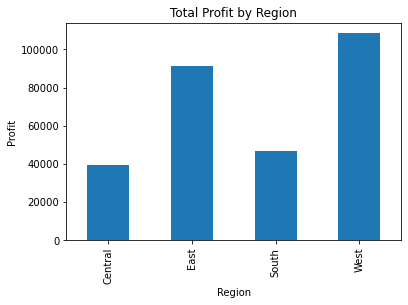

In [13]:
region_summary['Profit'].plot(kind='bar')

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

## Profit by Region Insights

The West region generated the highest total profit, making it the most profitable region during the period analysed.

Although the Central region generated higher sales than the South region, it produced the lowest total profit. This indicates that stronger sales do not necessarily translate into higher profitability.

The difference between regional sales and profit rankings suggests that some regions are more effective at converting sales into profit than others.

Further analysis is required to determine whether discounts, product mix, or other operational factors are affecting regional profitability.

## Why Analyse Monthly Sales Trends?

Monthly sales trend analysis is valuable because it helps a retail business understand how sales have changed over time, identify seasonal patterns, and evaluate overall business performance. By recognising periods of high and low demand, decision-makers can improve inventory planning, schedule marketing campaigns more effectively, and allocate resources efficiently. Understanding historical sales trends also provides a foundation for more accurate forecasting and better strategic decision-making.

## Monthly Sales Trend

This analysis examines how total sales changed over time.

Understanding monthly sales trends helps identify seasonal patterns, periods of strong and weak performance, and long-term changes in business activity.

In [14]:
monthly_sales = (
    df.groupby(['Year', 'Month'])['Sales']
      .sum()
      .reset_index()
)

monthly_sales

,Year,Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [15]:
monthly_sales['Year-Month'] = (
    monthly_sales['Year'].astype(str)
    + '-'
    + monthly_sales['Month'].astype(str).str.zfill(2)
)

monthly_sales

,Year,Month,Sales,Year-Month
0,2014,1,14236.8950,2014-01
1,2014,2,4519.8920,2014-02
2,2014,3,55691.0090,2014-03
3,2014,4,28295.3450,2014-04
4,2014,5,23648.2870,2014-05
5,2014,6,34595.1276,2014-06
6,2014,7,33946.3930,2014-07
7,2014,8,27909.4685,2014-08
8,2014,9,81777.3508,2014-09
9,2014,10,31453.3930,2014-10


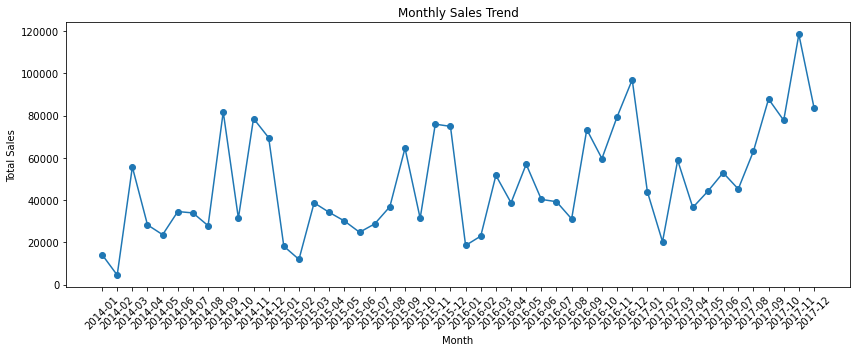

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales['Year-Month'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Monthly Sales Trend Insights

Monthly sales fluctuated throughout the analysis period but showed a clear overall upward trend, indicating that the business experienced growth over time.

Several months consistently recorded higher sales than others. In particular, September and November displayed recurring sales peaks across multiple years, suggesting the presence of seasonal demand patterns. November 2017 recorded the highest monthly sales in the dataset.

Conversely, February consistently recorded relatively low sales across all years, indicating a recurring period of weaker customer demand.

The repeating pattern of stronger sales during September and November, followed by weaker performance in February, suggests that the business experiences predictable seasonal fluctuations. Recognising these patterns can help management improve inventory planning, staffing decisions, and the timing of promotional campaigns.

## Customer Segment Performance

This analysis compares sales across customer segment types.

Understanding how different customer segments contribute to overall sales helps the business identify its most valuable customers and develop strategies to improve customer retention and revenue generation.

In [20]:
segment_summary = (
    df.groupby('Segment')['Sales']
      .sum()
      .sort_values(ascending=False)
)

segment_summary

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

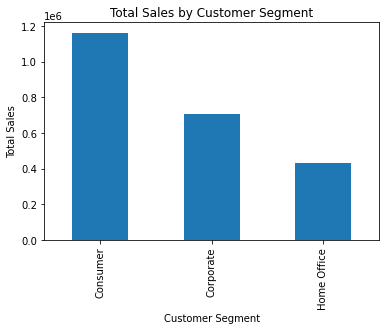

In [21]:
segment_summary.plot(kind='bar')

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.show()

## Customer Segment Insights

The Consumer segment generated the highest total sales, contributing more revenue than both the Corporate and Home Office segments.

The Corporate segment recorded the second-highest sales, while the Home Office segment generated the lowest total sales during the analysis period.

These results suggest that Consumer customers represent the business's largest source of revenue. Maintaining strong customer relationships and targeted marketing initiatives for this segment may help sustain future sales performance.

Further analysis is required to determine whether the Consumer segment is also the most profitable and whether the lower-performing segments present opportunities for future growth.

# Executive Summary

This descriptive analysis examined the overall sales performance of the retail business by analysing key performance indicators, product categories, regional performance, customer segments, and monthly sales trends.

The business generated over **$2.29  million in total sales and approximately  $286,397** in total profit across **5,009 customer orders*, indicating strong overall business performance.

Technology emerged as the strongest-performing product category, generating both the highest sales and the highest profit. In contrast, the Furniture category produced relatively high sales but considerably lower profit, suggesting that further investigation is required to understand the factors affecting its profitability.

Regional analysis showed that the West region generated the highest sales and profit, while the Central region generated lower profit than expected relative to its sales performance. This indicates that profitability differs across regions and warrants further investigation.

Monthly sales analysis revealed an overall upward sales trend with clear seasonal patterns. September and November consistently recorded higher sales, while February was generally the weakest-performing month. These recurring patterns can support inventory planning, staffing decisions, and promotional strategies.

Customer segment analysis showed that the Consumer segment generated the highest sales, making it the business's largest source of revenue.

Overall, the descriptive analysis provides a clear understanding of what happened during the analysis period. The findings establish a strong foundation for the next phase of the project, where diagnostic analytics will investigate the underlying factors driving these performance patterns.